In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sqrt

from sklearn.metrics import (mean_squared_error as MSE, mean_absolute_error as MAE, r2_score as R2,
                             explained_variance_score as EVS)
from sklearn.preprocessing import RobustScaler

from keras.models import load_model

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 8)

/home/bulent/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:34: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [2]:
def fraction_within_eps(y_true, y_pred, epsilon=0.5):
    # fraction of entries where abs(y_true - y_pred) < epsilon
    
    count = np.sum(np.abs(y_true - y_pred) <= epsilon)
    return count / y_true.shape[0]

yt = np.array([10, 10, 10, 10, 10])
yp = np.array([9.2, 9.7, 10.3, 10.2, 11])
print(fraction_within_eps(yt, yp, 0.6))
FIE = fraction_within_eps

0.6


In [3]:
def concorr(x, y):
    # Return Lin's concordance correlation coefficient
    # x, y are numpy arrays
    
    xm = x.mean()
    ym = y.mean()
    xv = x.var()
    yv = y.var()
    xycov = np.sum((x-xm)*(y-ym)) / x.shape[0]
    lin = 2*xycov / (xv + yv + (xm - ym)**2)
    return lin

xx = np.random.randn(10)
yy = xx + 10
print('R2 corr coef is {} whereas concordance corr coef is {}'.format(R2(yy,xx), concorr(yy,xx)))

R2 corr coef is -64.14024828884206 whereas concordance corr coef is 0.029788391478623392


In [4]:
with open('stations-6to31.pkl', 'rb') as f:
    datas = pickle.load(f)
    
x_train6_ = datas['x_train6']
y_train6 = datas['y_train6']
x_train_ = datas['x_train']
y_train = datas['y_train']
x_dev_ = datas['x_dev']
y_dev = datas['y_dev']
x_test_ = datas['x_test']
y_test = datas['y_test']

print(f'x_train shape: {x_train_.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [5]:
def scale_data(scaler, datas):
    # scaler is a scaling function from sklearn library
    # datas is a dictionary, containing 3 sets of x_data with keys - x_train, x_dev, x_test
    # fit on x_train and return the transformed sets of data
    
    x_train = scaler.fit_transform(datas['x_train'].astype(float))
    x_dev = scaler.transform(datas['x_dev'].astype(float))
    x_test = scaler.transform(datas['x_test'].astype(float))
    
    transformed = {'x_train': x_train, 'x_dev': x_dev, 'x_test': x_test}
    return transformed

data6_ = {'x_train': x_train6_, 'x_dev': x_dev_, 'x_test': x_test_}
data_ = {'x_train': x_train_, 'x_dev': x_dev_, 'x_test': x_test_}

data6 = scale_data(RobustScaler(), data6_)
data = scale_data(RobustScaler(), data_)

x_train6 = data6['x_train']
x_train = data['x_train']

x_dev6 = data6['x_dev']
x_dev = data['x_dev']

x_test6 = data6['x_test']
x_test = data['x_test']

print(f'x_train shape: {x_train.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 5), y_train shape: (52416,)
x_train6 shape: (10654, 5), y_train6 shape: (10654,)
x_dev shape: (9011, 5), y_dev shape: (9011,)
x_test shape: (16899, 5), y_test shape: (16899,)


In [6]:
data6_3v_ = {'x_train': x_train6_[:, [1, 3, 4, 0]], 'x_dev': x_dev_[:, [1, 3, 4, 0]], 'x_test': x_test_[:, [1, 3, 4, 0]]}
data_3v_ = {'x_train': x_train_[:, [1, 3, 4, 0]], 'x_dev': x_dev_[:, [1, 3, 4, 0]], 'x_test': x_test_[:, [1, 3, 4, 0]]}

data6_3v = scale_data(RobustScaler(), data6_3v_)
data_3v = scale_data(RobustScaler(), data_3v_)

x_train6_3v = data6_3v['x_train']
x_train_3v = data_3v['x_train']

x_dev6_3v = data6_3v['x_dev']
x_dev_3v = data_3v['x_dev']

x_test6_3v = data6_3v['x_test']
x_test_3v = data_3v['x_test']

print(f'x_train shape: {x_train_3v.shape}, y_train shape: {y_train.shape}')
print(f'x_train6 shape: {x_train6_3v.shape}, y_train6 shape: {y_train6.shape}')
print(f'x_dev shape: {x_dev_3v.shape}, y_dev shape: {y_dev.shape}')
print(f'x_test shape: {x_test_3v.shape}, y_test shape: {y_test.shape}')

x_train shape: (52416, 4), y_train shape: (52416,)
x_train6 shape: (10654, 4), y_train6 shape: (10654,)
x_dev shape: (9011, 4), y_dev shape: (9011,)
x_test shape: (16899, 4), y_test shape: (16899,)


In [7]:
# multiply the predictions by hh0 of respective dataset, and then compare

metrics_test6 = []
metrics_train6 = []
metrics_dev6 = []
print('Evaluating metrics for 6station trained NN \n')
for i in range(50):
    modelname = './6to31stats-3vars-h/6stations-h-nNPhiH0 {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test6_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev6_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train6_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_train6, p )
    rmse = sqrt( mse )
    mae = MAE( y_train6, p )
    r2 = R2( y_train6, p )
    evs = EVS( y_train6, p )
    fie_h = FIE( y_train6, p, 0.5)
    fie_o = FIE( y_train6, p, 1)
    fie_oh = FIE( y_train6, p, 1.5)
    lin = concorr(y_train6, p)

    metrics_train6.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 6station trained NN 

C01 » RMSE: 4.1479, MAE: 2.3272, R2: 0.7658, EVS: 0.7861, FIE_H: 0.2043, FIE_O: 0.3782, FIE_OH: 0.5281, LINCC: 0.8794
C01 » RMSE: 2.7540, MAE: 2.0090, R2: 0.8877, EVS: 0.9012, FIE_H: 0.1706, FIE_O: 0.3321, FIE_OH: 0.4796, LINCC: 0.9435
C01 » RMSE: 3.9076, MAE: 2.2081, R2: 0.8214, EVS: 0.8226, FIE_H: 0.1901, FIE_O: 0.3722, FIE_OH: 0.5252, LINCC: 0.9012
C02 » RMSE: 4.5540, MAE: 2.3023, R2: 0.7177, EVS: 0.7313, FIE_H: 0.2103, FIE_O: 0.3942, FIE_OH: 0.5450, LINCC: 0.8573
C02 » RMSE: 2.6891, MAE: 1.9446, R2: 0.8929, EVS: 0.9025, FIE_H: 0.1780, FIE_O: 0.3368, FIE_OH: 0.4940, LINCC: 0.9463
C02 » RMSE: 3.9535, MAE: 2.1427, R2: 0.8172, EVS: 0.8174, FIE_H: 0.2092, FIE_O: 0.3995, FIE_OH: 0.5620, LINCC: 0.8996
C03 » RMSE: 4.6587, MAE: 2.4336, R2: 0.7046, EVS: 0.7177, FIE_H: 0.1800, FIE_O: 0.3482, FIE_OH: 0.4978, LINCC: 0.8556
C03 » RMSE: 2.8667, MAE: 2.1294, R2: 0.8783, EVS: 0.8871, FIE_H: 0.1472, FIE_O: 0.2883, FIE_OH: 0.4324, LINCC: 0.9409
C03 » RMSE:

C24 » RMSE: 3.9541, MAE: 2.1721, R2: 0.8171, EVS: 0.8180, FIE_H: 0.1966, FIE_O: 0.3863, FIE_OH: 0.5491, LINCC: 0.9005
C25 » RMSE: 3.9614, MAE: 2.2491, R2: 0.7864, EVS: 0.8042, FIE_H: 0.2065, FIE_O: 0.3875, FIE_OH: 0.5388, LINCC: 0.8912
C25 » RMSE: 2.7884, MAE: 1.9967, R2: 0.8849, EVS: 0.8979, FIE_H: 0.1729, FIE_O: 0.3471, FIE_OH: 0.4902, LINCC: 0.9431
C25 » RMSE: 3.9689, MAE: 2.1641, R2: 0.8158, EVS: 0.8164, FIE_H: 0.2013, FIE_O: 0.3897, FIE_OH: 0.5557, LINCC: 0.9004
C26 » RMSE: 4.6597, MAE: 2.3951, R2: 0.7045, EVS: 0.7195, FIE_H: 0.1959, FIE_O: 0.3738, FIE_OH: 0.5235, LINCC: 0.8529
C26 » RMSE: 2.8439, MAE: 2.0735, R2: 0.8802, EVS: 0.8908, FIE_H: 0.1636, FIE_O: 0.3254, FIE_OH: 0.4771, LINCC: 0.9401
C26 » RMSE: 3.8786, MAE: 2.1455, R2: 0.8241, EVS: 0.8247, FIE_H: 0.2214, FIE_O: 0.4052, FIE_OH: 0.5543, LINCC: 0.9032
C27 » RMSE: 4.3666, MAE: 2.2728, R2: 0.7405, EVS: 0.7523, FIE_H: 0.2068, FIE_O: 0.3916, FIE_OH: 0.5425, LINCC: 0.8695
C27 » RMSE: 2.7236, MAE: 1.9871, R2: 0.8901, EVS: 0.8992

C48 » RMSE: 4.2027, MAE: 2.5081, R2: 0.7596, EVS: 0.7883, FIE_H: 0.1699, FIE_O: 0.3194, FIE_OH: 0.4591, LINCC: 0.8729
C48 » RMSE: 2.9407, MAE: 2.1534, R2: 0.8719, EVS: 0.8975, FIE_H: 0.1668, FIE_O: 0.3296, FIE_OH: 0.4665, LINCC: 0.9338
C48 » RMSE: 4.1008, MAE: 2.4929, R2: 0.8033, EVS: 0.8067, FIE_H: 0.1678, FIE_O: 0.3176, FIE_OH: 0.4503, LINCC: 0.8882
C49 » RMSE: 4.2148, MAE: 2.3327, R2: 0.7582, EVS: 0.7724, FIE_H: 0.1969, FIE_O: 0.3771, FIE_OH: 0.5248, LINCC: 0.8793
C49 » RMSE: 2.8176, MAE: 2.0707, R2: 0.8824, EVS: 0.8929, FIE_H: 0.1595, FIE_O: 0.3189, FIE_OH: 0.4658, LINCC: 0.9421
C49 » RMSE: 3.9640, MAE: 2.1827, R2: 0.8162, EVS: 0.8164, FIE_H: 0.1950, FIE_O: 0.3746, FIE_OH: 0.5368, LINCC: 0.9012
C50 » RMSE: 4.3317, MAE: 2.2884, R2: 0.7446, EVS: 0.7599, FIE_H: 0.2056, FIE_O: 0.3920, FIE_OH: 0.5466, LINCC: 0.8704
C50 » RMSE: 2.7597, MAE: 1.9720, R2: 0.8872, EVS: 0.8987, FIE_H: 0.1763, FIE_O: 0.3426, FIE_OH: 0.5031, LINCC: 0.9432
C50 » RMSE: 3.9367, MAE: 2.1264, R2: 0.8187, EVS: 0.8192

In [8]:
metrics_test31 = []
metrics_train31 = []
metrics_dev31 = []
print('Evaluating metrics for 31station trained NN \n')
for i in range(50):
    modelname = './6to31stats-3vars-h/31stations-h-nNPhiH0 {}.h5'.format(i+1)
    model = load_model(modelname)

    # predict on test set and evaluate the metrics
    p = model.predict( x_test_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_test, p )
    rmse = sqrt( mse )
    mae = MAE( y_test, p )
    r2 = R2( y_test, p )
    evs = EVS( y_test, p )
    fie_h = FIE( y_test, p, 0.5)
    fie_o = FIE( y_test, p, 1)
    fie_oh = FIE( y_test, p, 1.5)
    lin = concorr(y_test, p)

    metrics_test31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Validation set
    p = model.predict( x_dev_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_dev, p )
    rmse = sqrt( mse )
    mae = MAE( y_dev, p )
    r2 = R2( y_dev, p )
    evs = EVS( y_dev, p )
    fie_h = FIE( y_dev, p, 0.5)
    fie_o = FIE( y_dev, p, 1)
    fie_oh = FIE( y_dev, p, 1.5)
    lin = concorr(y_dev, p)

    metrics_dev31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    # Training set
    p = model.predict( x_train_3v, batch_size=64 )
    p = np.squeeze(p)
    mse = MSE( y_train, p )
    rmse = sqrt( mse )
    mae = MAE( y_train, p )
    r2 = R2( y_train, p )
    evs = EVS( y_train, p )
    fie_h = FIE( y_train, p, 0.5)
    fie_o = FIE( y_train, p, 1)
    fie_oh = FIE( y_train, p, 1.5)
    lin = concorr(y_train, p)

    metrics_train31.append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

    print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
          'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                        rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for 31station trained NN 

C01 » RMSE: 4.6520, MAE: 2.1034, R2: 0.7054, EVS: 0.7127, FIE_H: 0.2604, FIE_O: 0.4761, FIE_OH: 0.6344, LINCC: 0.8526
C01 » RMSE: 2.3275, MAE: 1.5281, R2: 0.9198, EVS: 0.9218, FIE_H: 0.2586, FIE_O: 0.4835, FIE_OH: 0.6521, LINCC: 0.9596
C01 » RMSE: 3.1517, MAE: 1.7043, R2: 0.8666, EVS: 0.8669, FIE_H: 0.2600, FIE_O: 0.4787, FIE_OH: 0.6417, LINCC: 0.9299
C02 » RMSE: 4.0054, MAE: 2.0552, R2: 0.7816, EVS: 0.7925, FIE_H: 0.2568, FIE_O: 0.4648, FIE_OH: 0.6198, LINCC: 0.8857
C02 » RMSE: 2.3025, MAE: 1.5210, R2: 0.9215, EVS: 0.9238, FIE_H: 0.2637, FIE_O: 0.4837, FIE_OH: 0.6495, LINCC: 0.9594
C02 » RMSE: 3.0696, MAE: 1.7204, R2: 0.8735, EVS: 0.8737, FIE_H: 0.2544, FIE_O: 0.4693, FIE_OH: 0.6315, LINCC: 0.9318
C03 » RMSE: 3.9674, MAE: 2.0751, R2: 0.7858, EVS: 0.7975, FIE_H: 0.2509, FIE_O: 0.4564, FIE_OH: 0.6081, LINCC: 0.8884
C03 » RMSE: 2.3731, MAE: 1.5831, R2: 0.9166, EVS: 0.9209, FIE_H: 0.2529, FIE_O: 0.4652, FIE_OH: 0.6322, LINCC: 0.9577
C03 » RMSE

C24 » RMSE: 2.3038, MAE: 1.5084, R2: 0.9214, EVS: 0.9251, FIE_H: 0.2605, FIE_O: 0.4965, FIE_OH: 0.6575, LINCC: 0.9604
C24 » RMSE: 3.0774, MAE: 1.6930, R2: 0.8728, EVS: 0.8729, FIE_H: 0.2614, FIE_O: 0.4824, FIE_OH: 0.6477, LINCC: 0.9331
C25 » RMSE: 3.9571, MAE: 2.0254, R2: 0.7869, EVS: 0.7950, FIE_H: 0.2584, FIE_O: 0.4786, FIE_OH: 0.6338, LINCC: 0.8918
C25 » RMSE: 2.3554, MAE: 1.5659, R2: 0.9178, EVS: 0.9199, FIE_H: 0.2496, FIE_O: 0.4683, FIE_OH: 0.6357, LINCC: 0.9593
C25 » RMSE: 3.0791, MAE: 1.6954, R2: 0.8727, EVS: 0.8730, FIE_H: 0.2597, FIE_O: 0.4810, FIE_OH: 0.6458, LINCC: 0.9341
C26 » RMSE: 4.1471, MAE: 2.1613, R2: 0.7659, EVS: 0.7793, FIE_H: 0.2385, FIE_O: 0.4390, FIE_OH: 0.5959, LINCC: 0.8828
C26 » RMSE: 2.4646, MAE: 1.6821, R2: 0.9100, EVS: 0.9159, FIE_H: 0.2327, FIE_O: 0.4287, FIE_OH: 0.5909, LINCC: 0.9557
C26 » RMSE: 3.0958, MAE: 1.7542, R2: 0.8713, EVS: 0.8714, FIE_H: 0.2362, FIE_O: 0.4551, FIE_OH: 0.6236, LINCC: 0.9335
C27 » RMSE: 4.0116, MAE: 2.1080, R2: 0.7809, EVS: 0.7974

C47 » RMSE: 3.0917, MAE: 1.7251, R2: 0.8716, EVS: 0.8721, FIE_H: 0.2486, FIE_O: 0.4672, FIE_OH: 0.6365, LINCC: 0.9327
C48 » RMSE: 3.9996, MAE: 2.0533, R2: 0.7823, EVS: 0.7963, FIE_H: 0.2488, FIE_O: 0.4645, FIE_OH: 0.6242, LINCC: 0.8879
C48 » RMSE: 2.3634, MAE: 1.5353, R2: 0.9173, EVS: 0.9220, FIE_H: 0.2582, FIE_O: 0.4849, FIE_OH: 0.6579, LINCC: 0.9587
C48 » RMSE: 3.0821, MAE: 1.7054, R2: 0.8724, EVS: 0.8725, FIE_H: 0.2548, FIE_O: 0.4778, FIE_OH: 0.6458, LINCC: 0.9332
C49 » RMSE: 4.4383, MAE: 2.2413, R2: 0.7319, EVS: 0.7523, FIE_H: 0.2437, FIE_O: 0.4443, FIE_OH: 0.5994, LINCC: 0.8627
C49 » RMSE: 2.4336, MAE: 1.6021, R2: 0.9123, EVS: 0.9202, FIE_H: 0.2487, FIE_O: 0.4600, FIE_OH: 0.6313, LINCC: 0.9558
C49 » RMSE: 3.0851, MAE: 1.7086, R2: 0.8722, EVS: 0.8724, FIE_H: 0.2567, FIE_O: 0.4785, FIE_OH: 0.6425, LINCC: 0.9329
C50 » RMSE: 3.9357, MAE: 2.0333, R2: 0.7892, EVS: 0.7985, FIE_H: 0.2590, FIE_O: 0.4700, FIE_OH: 0.6244, LINCC: 0.8910
C50 » RMSE: 2.3576, MAE: 1.5818, R2: 0.9177, EVS: 0.9201

In [9]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

with open('measures_6to31_nNPhi_h.pkl', 'wb') as f:
    pickle.dump(measures, f)

In [9]:
measures = {'tr6': metrics_train6, 'te6': metrics_test6, 'de6': metrics_dev6,
            'tr31': metrics_train31, 'te31': metrics_test31, 'de31': metrics_dev31}

mess = ['rmse', 'mae', 'r2', 'evs', 'fie_h', 'fie_o', 'fie_oh', 'lin']
test6 = np.array(measures['te6']).T # 8x50
test31 = np.array(measures['te31']).T
for i in range(8):
    exec(f'{mess[i]} = np.array([test6[i], test31[i]])')
    exec(f'{mess[i]} = {mess[i]}.T')
    
print(rmse.shape)

(50, 2)


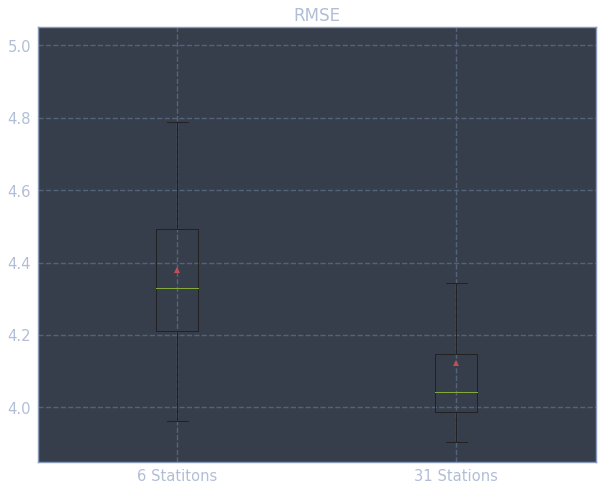

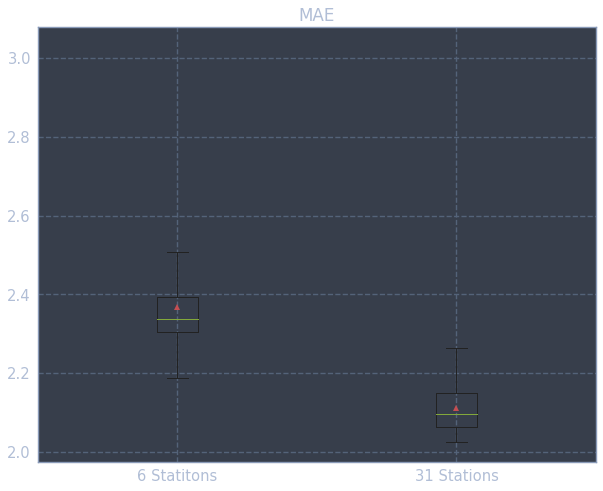

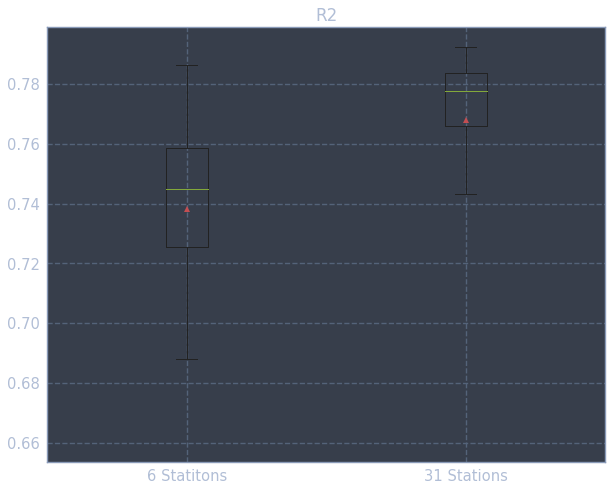

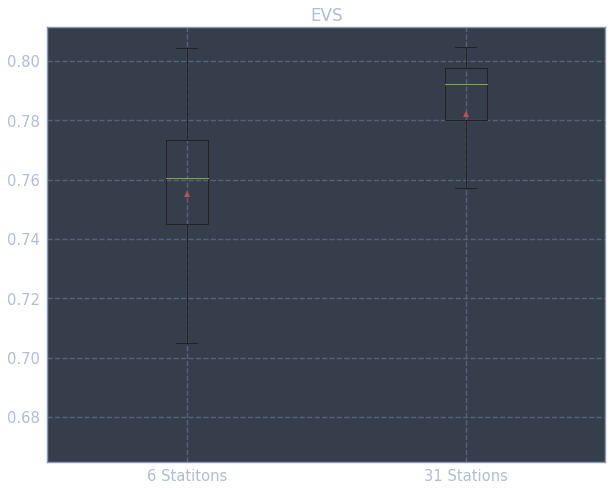

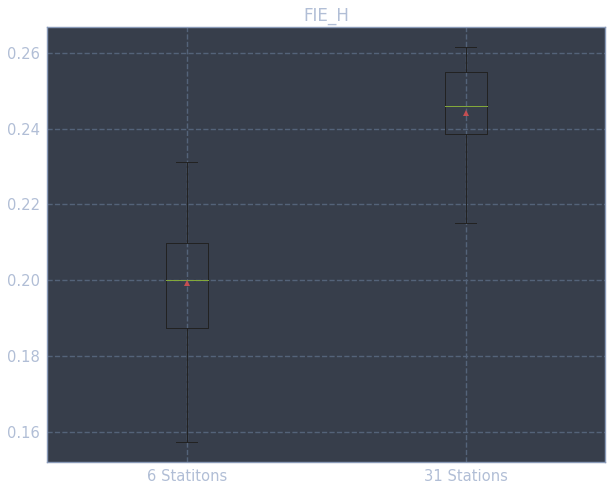

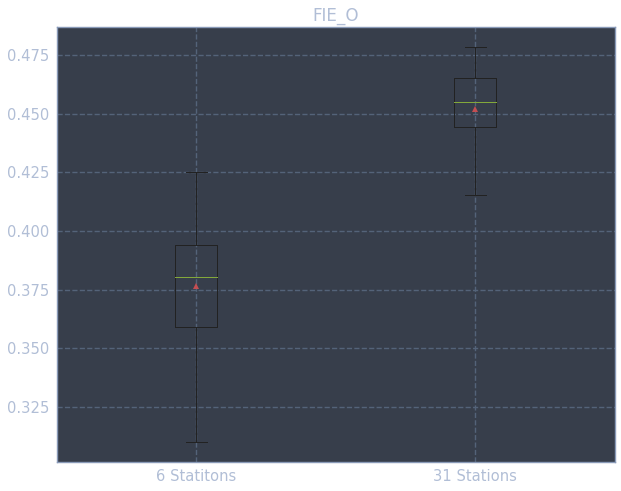

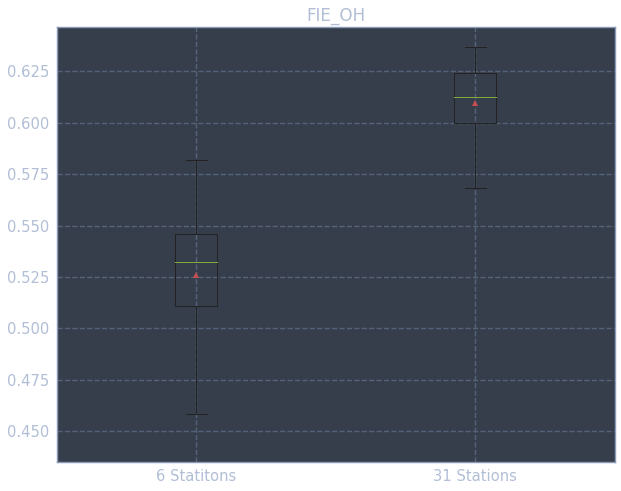

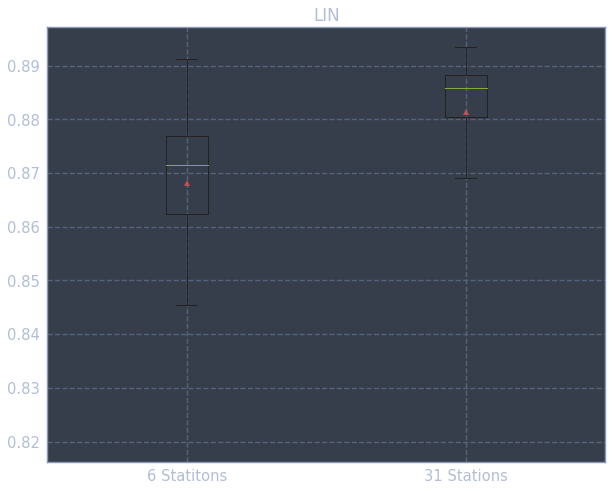

In [10]:
# I want a boxplot for each measure, showing test set comparison for 6station and 31station trained NNs
# plt.boxplot(x) makes a box for each column in x, so I need to feed 50x2 arrays to it

n = 0
for m in mess:
    plt.figure(n)
    exec(f'plt.boxplot({m}, labels=["6 Statitons", "31 Stations"], showmeans=True)')
    plt.title(m.upper())
    n += 1